## How to Run This Notebook
* This project was developed in Jupyter Notebook using Python.
* The main dataset is hour.csv (Capital Bikeshare hourly data).
     *Put hour.csv in the same folder as this notebook before running.

## 1.Libraries
The notebook uses these main libraries:
* numpy, pandas – data handling
* matplotlib, seaborn – plots
* scikit-learn – machine learning models & metrics
* xgboost, lightgbm, catboost – gradient-boosting models
* optuna – hyperparameter tuning
* requests – calling the Open-Meteo weather API
* joblib – saving the final model
* All libraries were already installed in my environment except optuna, which I installed specifically for
* hyperparameter tuning using: "pip install optuna"
* If you see an import error, please install the missing package with "pip install <package-name>".

## 2. Global Metrics & Helper Metrics
At the top of the notebook:
    *Configure global plotting and warning settings (to make graphs clear and hide unnecessary warnings).
    *Set a random seed for reproducibility.
    *Define the smape function, which is the main error metric used to evaluate the models.
You don’t need to change these; just make sure these cells run before anything else.

## 3. How to Execute the Notebook
1.Open this notebook in Jupyter.
2.Check that CSV_PATH = "hour.csv" is correct for your folder.
3.From the menu, choose: Kernel → Restart & Run All (or run each cell from top to bottom in order).

* The notebook will then:
1. Load and clean the data
2. Perform EDA (plots)
3. Do feature engineering and build the final feature set
4. Train several baseline models
5. Run hyperparameter tuning with Optuna on the selected model(s)
6. Evaluate the final best model
7. Generate a 24-hour live forecast using real-time weather from the Open-Meteo API

Note: 
* The baseline model training cells are relatively fast.
* The Optuna hyperparameter tuning cells are much slower because they train many versions of the model with time-series cross-validation.
* If you want faster runs, you can reduce n_trials inside the tuning functions (for example, from 40 trials to 10–15).

## 4. Internet Requirement
* The live 24-hour forecast section at the end calls the Open-Meteo API.
* For that part to work, you need an active internet connection.
* If there is no internet, you can still run everything up to the modeling and evaluation sections; just skip the final “live forecast” cells.

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
import time

from datetime import datetime, timedelta
import zoneinfo
from collections import deque
from pandas.tseries.holiday import USFederalHolidayCalendar

# Models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    confusion_matrix,
)

# Optuna for model iteration / tuning
from sklearn.model_selection import TimeSeriesSplit
import optuna
import joblib


# Global Settings

In [2]:
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 130
plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

LOCAL_TZ = zoneinfo.ZoneInfo("America/New_York")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Time-series CV for Optuna
tscv = TimeSeriesSplit(n_splits=5)

# Helper Metrics

In [3]:
def smape(y_true, y_pred):
    """Symmetric MAPE in %, robust for demand forecasting."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 100.0 * np.mean(
        2.0 * np.abs(y_pred - y_true)
        / (np.abs(y_true) + np.abs(y_pred) + 1e-10)
    )


# File Path

In [4]:
CSV_PATH = "hour.csv"
df = pd.read_csv(CSV_PATH)
print("Raw shape:", df.shape)

Raw shape: (17379, 17)


# Data Cleaning

### Removing Duplicates

In [5]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Removed {before - after} duplicate rows")


Removed 0 duplicate rows


### Proper datetime & dtypes

In [6]:
df["dteday"] = pd.to_datetime(df["dteday"], errors="coerce")
df["datetime"] = df["dteday"] + pd.to_timedelta(df["hr"], unit="h")

# Cast numeric types
int_cols = ["instant", "season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]
for c in int_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")

float_cols = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]
for c in float_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

### Drop invalid essentials

In [7]:
before = len(df)
df = df.dropna(subset=["datetime", "cnt"]).reset_index(drop=True)
after = len(df)
print(f"Dropped {before - after} rows with missing datetime/cnt")

Dropped 0 rows with missing datetime/cnt


### Removing Negative Targets & Sorting Time

In [8]:
df = df[df["cnt"] >= 0].reset_index(drop=True)
df = df.sort_values("datetime").reset_index(drop=True)

### Outlier Flag

In [9]:
Q1, Q3 = df["cnt"].quantile(0.25), df["cnt"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
df["is_outlier_cnt"] = ((df["cnt"] < lower) | (df["cnt"] > upper)).astype(int)
print(f"Flagged {df['is_outlier_cnt'].sum()} potential outliers in cnt")


Flagged 505 potential outliers in cnt


### Check for gaps in hourly timeline

In [10]:
df_temp = df.set_index("datetime")
full_range = pd.date_range(df_temp.index.min(), df_temp.index.max(), freq="h")
missing = full_range.difference(df_temp.index)
if len(missing) > 0:
    print(f"WARNING: {len(missing)} missing hours detected!")
else:
    print("No gaps in hourly timeline")
df = df_temp.reset_index()

### Drop ID-like columns

In [11]:
df = df.drop(columns=["instant", "casual", "registered"], errors="ignore")

print(f"Final cleaned shape: {df.shape}")
print(f"Date range: {df['datetime'].min().date()} → {df['datetime'].max().date()}")

print("\nSample of cleaned data:")
display(df.head(8))
display(df.describe(include="all").T)

Final cleaned shape: (17379, 16)
Date range: 2011-01-01 → 2012-12-31

Sample of cleaned data:


,datetime,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,is_outlier_cnt
0,2011-01-01 00:00:00,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,16,0
1,2011-01-01 01:00:00,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,40,0
2,2011-01-01 02:00:00,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,32,0
3,2011-01-01 03:00:00,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,13,0
4,2011-01-01 04:00:00,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,1,0
5,2011-01-01 05:00:00,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,1,0
6,2011-01-01 06:00:00,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0
7,2011-01-01 07:00:00,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,3,0


,count,mean,min,25%,50%,75%,max,std
datetime,17379,2012-01-02 15:41:22.858622464,2011-01-01 00:00:00,2011-07-04 22:30:00,2012-01-02 21:00:00,2012-07-02 06:30:00,2012-12-31 23:00:00,NaN
dteday,17379,2012-01-02 04:08:34.552045568,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,17379.0,2.50164,1.0,2.0,3.0,3.0,4.0,1.106918
yr,17379.0,0.502561,0.0,0.0,1.0,1.0,1.0,0.500008
mnth,17379.0,6.537775,1.0,4.0,7.0,10.0,12.0,3.438776
hr,17379.0,11.546752,0.0,6.0,12.0,18.0,23.0,6.914405
holiday,17379.0,0.02877,0.0,0.0,0.0,0.0,1.0,0.167165
weekday,17379.0,3.003683,0.0,1.0,3.0,5.0,6.0,2.005771
workingday,17379.0,0.682721,0.0,0.0,1.0,1.0,1.0,0.465431
weathersit,17379.0,1.425283,1.0,1.0,1.0,2.0,4.0,0.639357


# Exploratory Data Analysis (EDA)

In [12]:
print("\nSample of cleaned data:")
display(df.head(8))
display(df.describe(include="all").T)


Sample of cleaned data:


,datetime,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,is_outlier_cnt
0,2011-01-01 00:00:00,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,16,0
1,2011-01-01 01:00:00,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,40,0
2,2011-01-01 02:00:00,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,32,0
3,2011-01-01 03:00:00,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,13,0
4,2011-01-01 04:00:00,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,1,0
5,2011-01-01 05:00:00,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,1,0
6,2011-01-01 06:00:00,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0
7,2011-01-01 07:00:00,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,3,0


,count,mean,min,25%,50%,75%,max,std
datetime,17379,2012-01-02 15:41:22.858622464,2011-01-01 00:00:00,2011-07-04 22:30:00,2012-01-02 21:00:00,2012-07-02 06:30:00,2012-12-31 23:00:00,NaN
dteday,17379,2012-01-02 04:08:34.552045568,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,17379.0,2.50164,1.0,2.0,3.0,3.0,4.0,1.106918
yr,17379.0,0.502561,0.0,0.0,1.0,1.0,1.0,0.500008
mnth,17379.0,6.537775,1.0,4.0,7.0,10.0,12.0,3.438776
hr,17379.0,11.546752,0.0,6.0,12.0,18.0,23.0,6.914405
holiday,17379.0,0.02877,0.0,0.0,0.0,0.0,1.0,0.167165
weekday,17379.0,3.003683,0.0,1.0,3.0,5.0,6.0,2.005771
workingday,17379.0,0.682721,0.0,0.0,1.0,1.0,1.0,0.465431
weathersit,17379.0,1.425283,1.0,1.0,1.0,2.0,4.0,0.639357


### Distribution of target

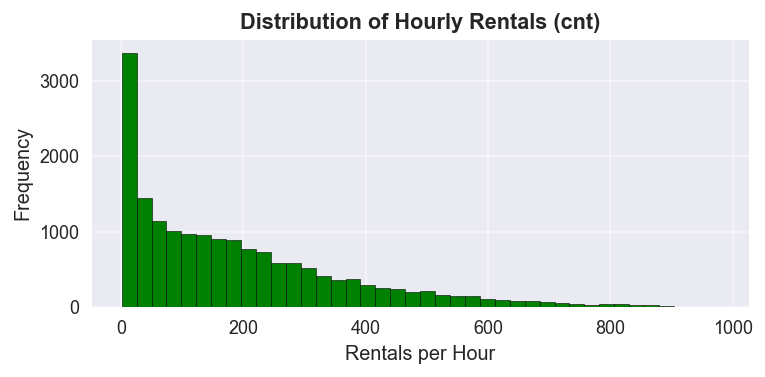

In [54]:
plt.figure(figsize=(6, 3))
plt.hist(df["cnt"], bins=40, edgecolor="black", color="green")
plt.title("Distribution of Hourly Rentals (cnt)", fontweight="bold")
plt.xlabel("Rentals per Hour")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

### Box Plot of Cnt

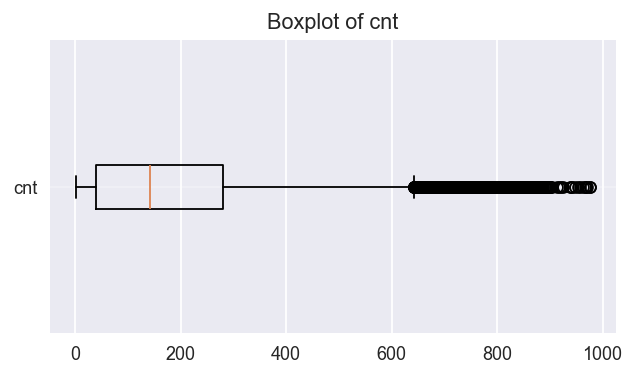

In [78]:
plt.figure(figsize=(5,3))
plt.boxplot(df["cnt"],labels=["cnt"], vert=False)
plt.title("Boxplot of cnt")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Hourly, weekday, monthly patterns

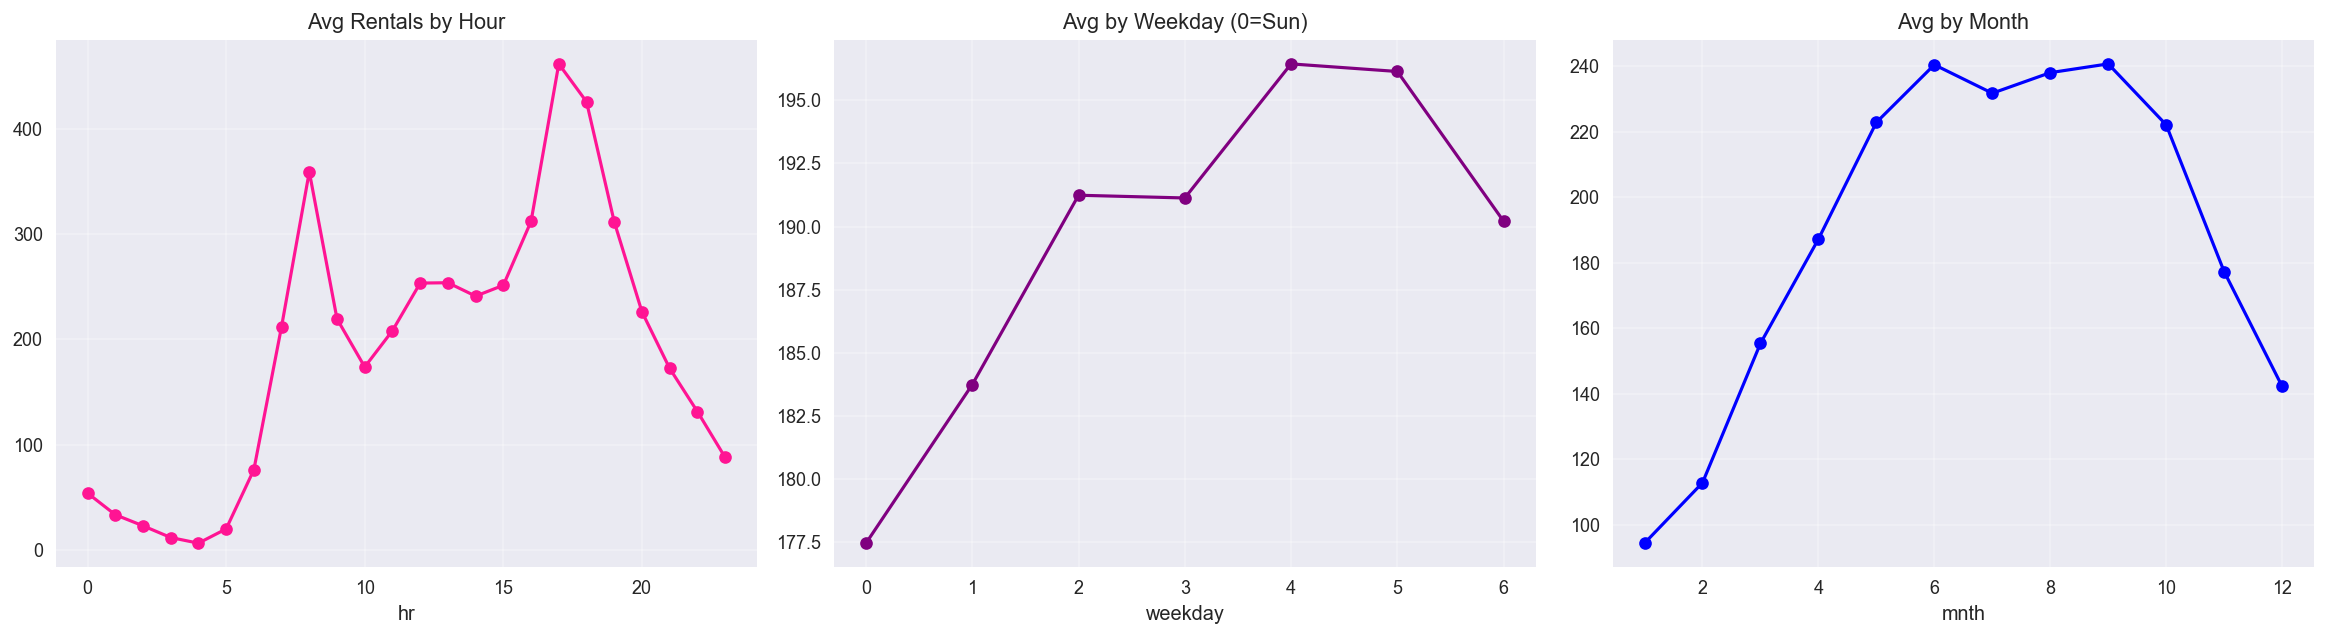

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df.groupby("hr")["cnt"].mean().plot(ax=axes[0], marker="o", title="Avg Rentals by Hour", color="deeppink")
df.groupby("weekday")["cnt"].mean().plot(ax=axes[1], marker="o", title="Avg by Weekday (0=Sun)", color="purple")
df.groupby("mnth")["cnt"].mean().plot(ax=axes[2], marker="o", title="Avg by Month", color="blue")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Rentals v/s Weather Variables

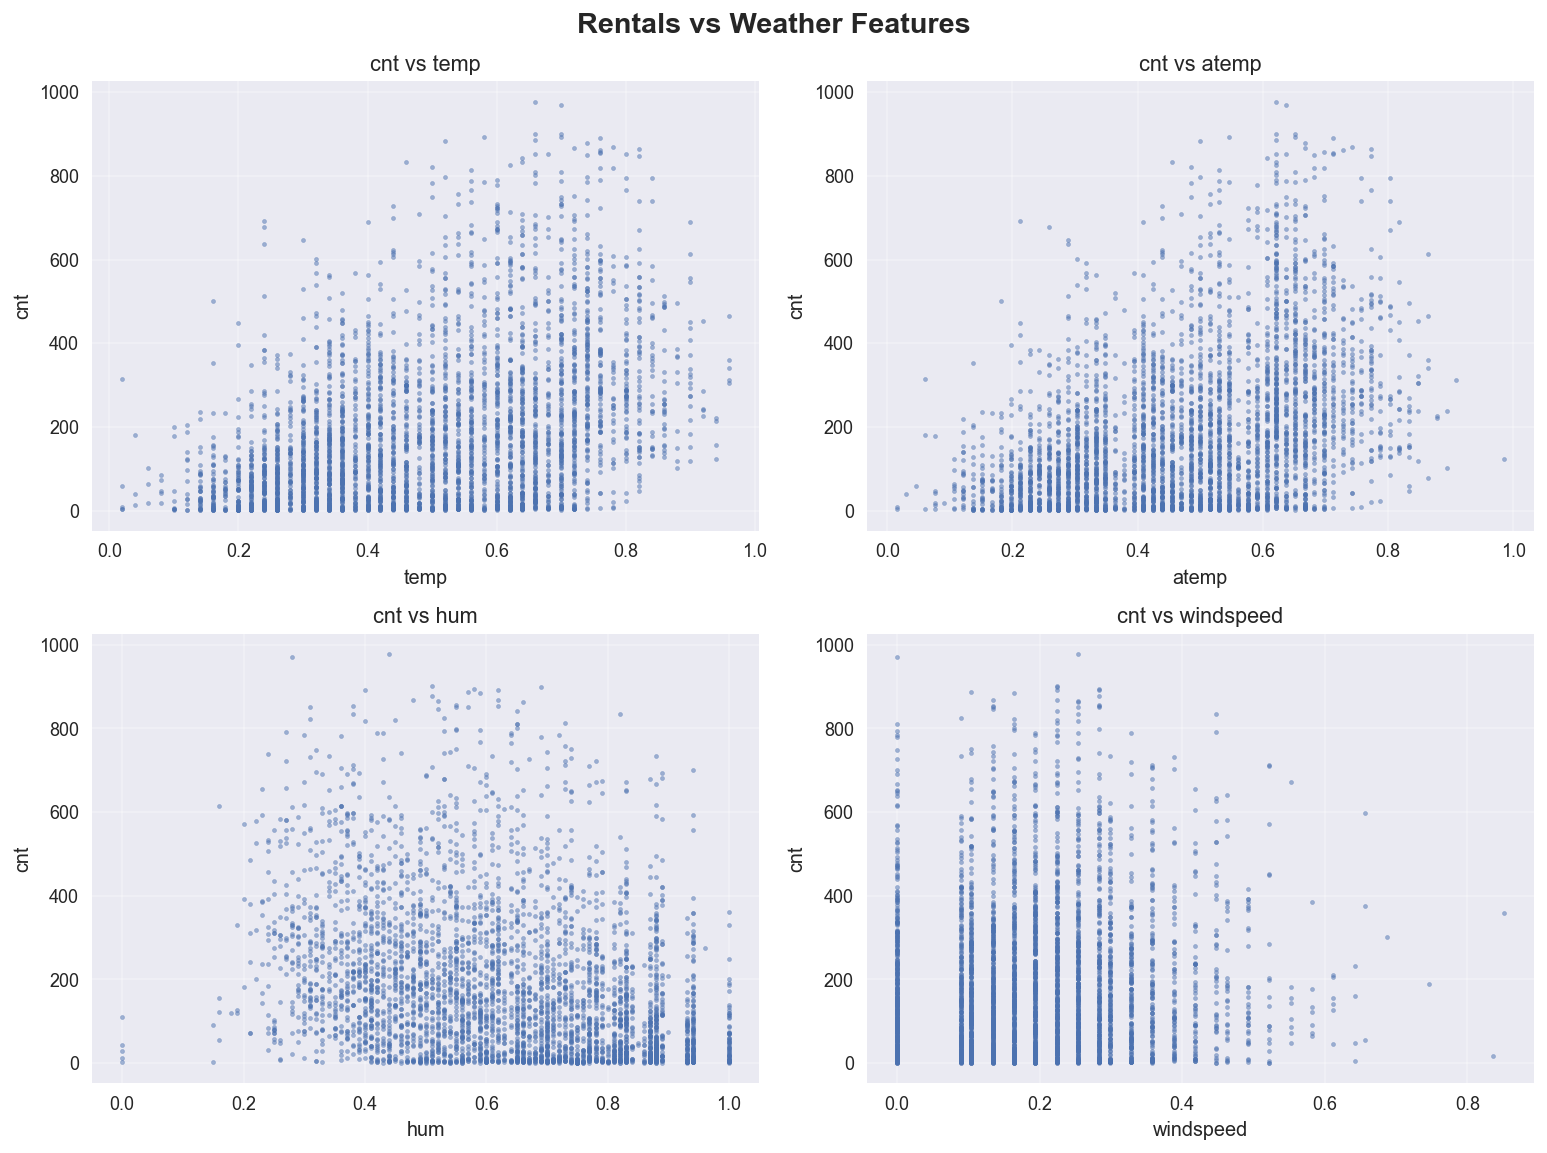

In [57]:
weather_cols = ["temp", "atemp", "hum", "windspeed"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()
for i, col in enumerate(weather_cols):
    s = df[[col, "cnt"]].dropna().sample(min(4000, len(df)), random_state=RANDOM_STATE)
    axes[i].scatter(s[col], s["cnt"], alpha=0.5, s=5)
    axes[i].set_title(f"cnt vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("cnt")
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Rentals vs Weather Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Correlation heatmap

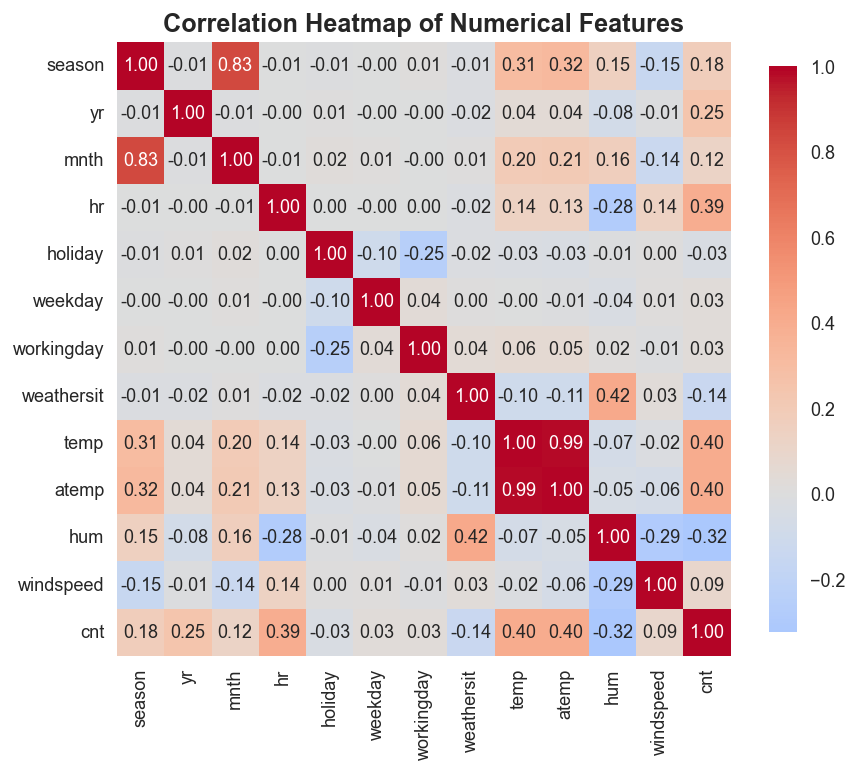

In [58]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr_cols = [c for c in num_cols if c not in ["is_outlier_cnt"]]
corr = df[corr_cols].corr()

plt.figure(figsize=(7,9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.5},
)
plt.title("Correlation Heatmap of Numerical Features", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

### Time series overview

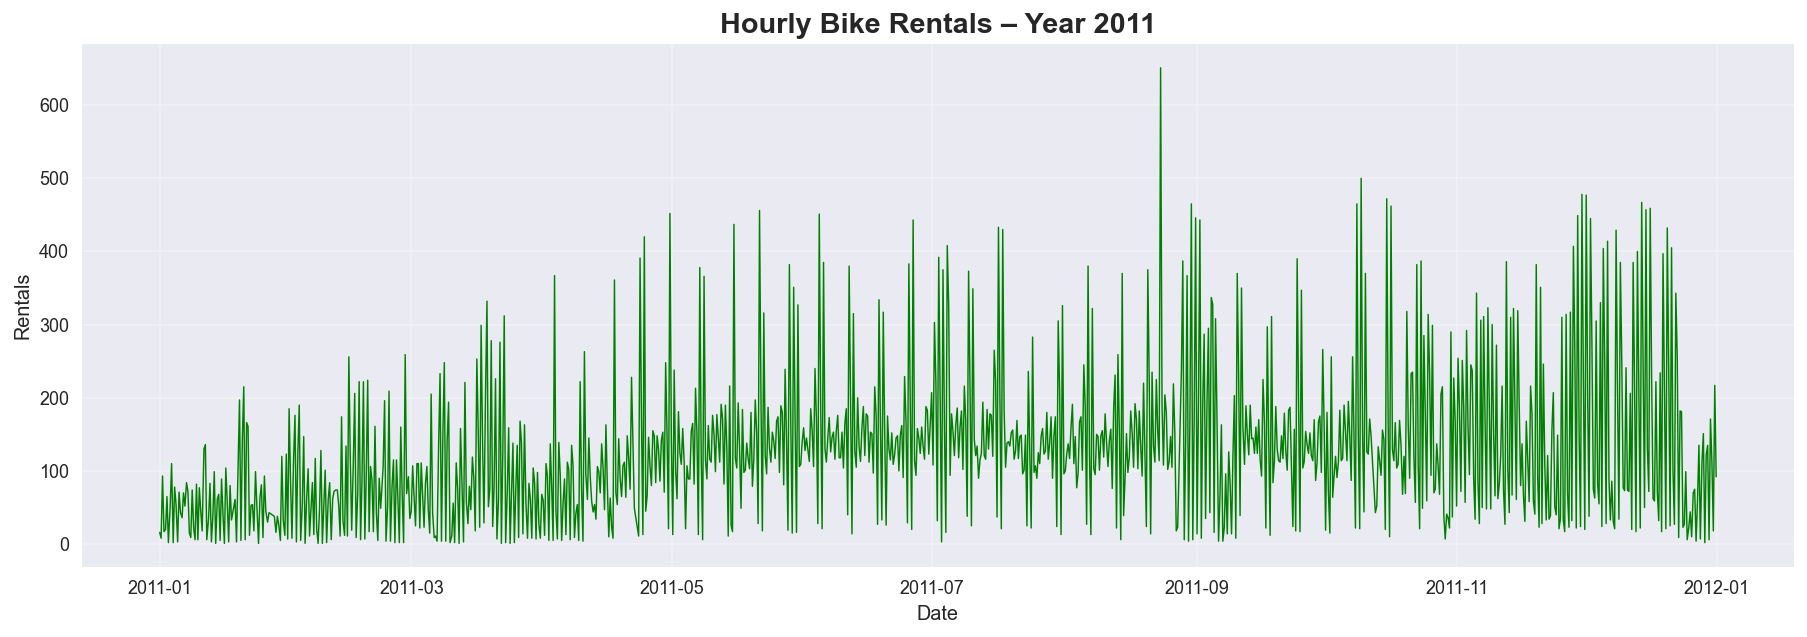

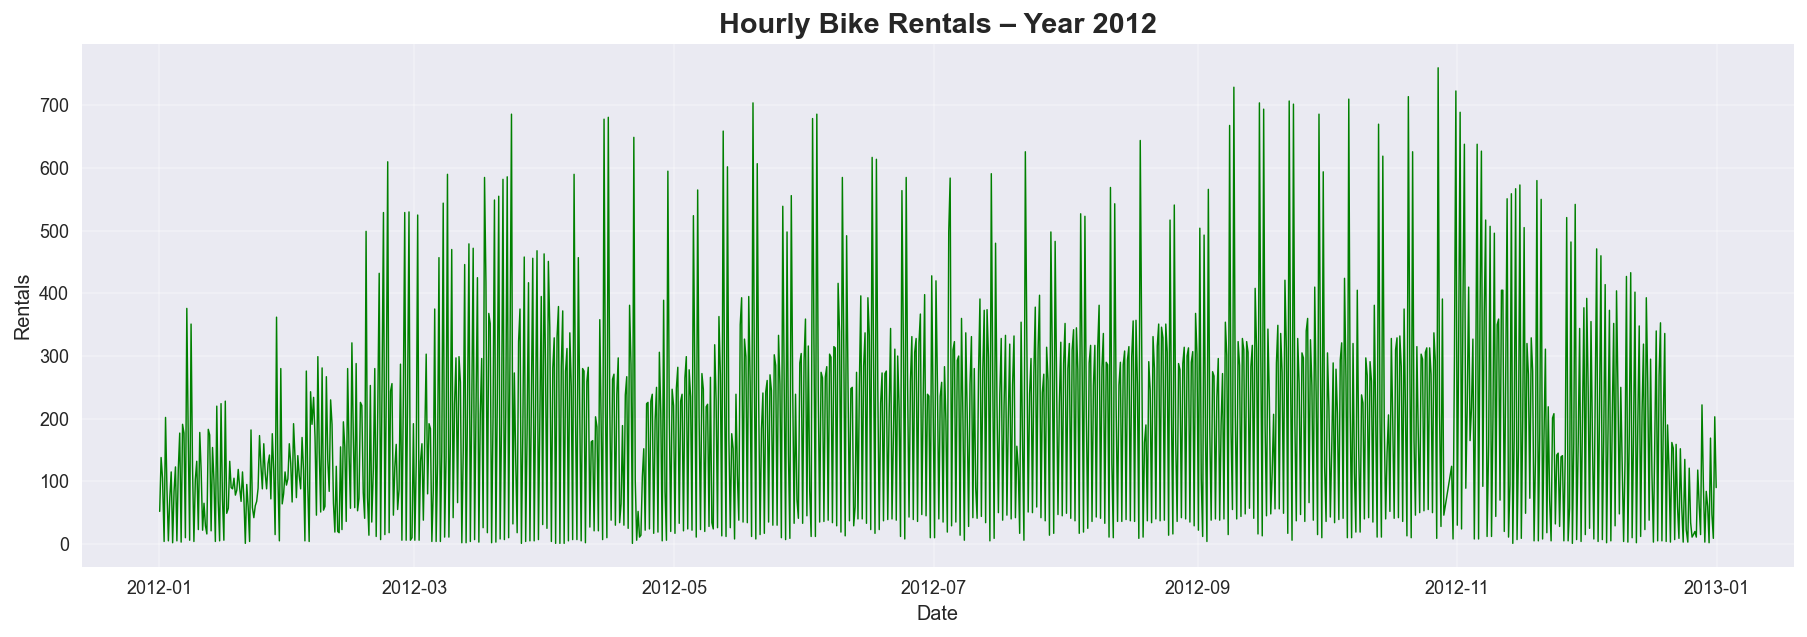

In [59]:

# Year 2011
step = max(1, len(df) // 2000)

plt.figure(figsize=(14, 5))
plt.plot(df["datetime"].iloc[::step][df["datetime"].dt.year == 2011],
         df["cnt"].iloc[::step][df["datetime"].dt.year == 2011],
         linewidth=0.8, color="green")
plt.title("Hourly Bike Rentals – Year 2011", fontweight="bold", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Rentals")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Year 2012
plt.figure(figsize=(14, 5))
plt.plot(df["datetime"].iloc[::step][df["datetime"].dt.year == 2012],
         df["cnt"].iloc[::step][df["datetime"].dt.year == 2012],
         linewidth=0.8, color="green")
plt.title("Hourly Bike Rentals – Year 2012", fontweight="bold", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Rentals")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Data Preprocessing

### Last 50 days as unseen future test

In [19]:
cutoff_date = df["datetime"].max() - pd.Timedelta(days=50)
print(f"\nTrain period: {df['datetime'].min().date()} → {cutoff_date.date()}")
print(f"Test period : {cutoff_date.date()} → {df['datetime'].max().date()} (last 50 days)")


Train period: 2011-01-01 → 2012-11-11
Test period : 2012-11-11 → 2012-12-31 (last 50 days)


### Feature Engineering

In [70]:
def create_features_final(df_full: pd.DataFrame) -> pd.DataFrame:

    df = df_full.copy()

    # Cyclic encodings
    df["hour_sin"]   = np.sin(2 * np.pi * df["hr"]      / 24)
    df["hour_cos"]   = np.cos(2 * np.pi * df["hr"]      / 24)
    df["day_sin"]    = np.sin(2 * np.pi * df["weekday"] / 7)
    df["month_sin"]  = np.sin(2 * np.pi * df["mnth"]    / 12)
    df["month_cos"]  = np.cos(2 * np.pi * df["mnth"]    / 12)

    # Calendar features
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start="2011-01-01", end="2013-01-01")
    df["is_holiday"] = df["dteday"].isin(holidays.date).astype(int)
    df["is_weekend"] = df["weekday"].isin([0, 6]).astype(int)  # weekday 0=Sunday in dataset

    # Trend
    df["days_since_start"] = (df["datetime"] - df["datetime"].min()).dt.days

    # Weather interactions
    df["feels_like"]  = df["temp"] * (1 - df["hum"])
    df["temp_sq"]     = df["temp"] ** 2
    df["temp_cubed"]  = df["temp"] ** 3

    # Rush hour interactions
    df["is_rush_hour"] = df["hr"].isin([7, 8, 9, 17, 18, 19]).astype(int)
    df["rush_work"]    = df["is_rush_hour"] * df["workingday"]

    # Lags (Used in live_forecast)
    for lag in [1, 2, 24, 48, 168]:
        df[f"lag_{lag}h"] = df["cnt"].shift(lag)

    # Rolling statistics (Used in live_forecast)
    # Past-only: shift(1)
    df["roll_mean_3h"]  = df["cnt"].rolling(3,  min_periods=1).mean().shift(1)
    df["roll_mean_12h"] = df["cnt"].rolling(12, min_periods=1).mean().shift(1)
    df["roll_mean_24h"] = df["cnt"].rolling(24, min_periods=1).mean().shift(1)
    df["roll_std_24h"]  = df["cnt"].rolling(24, min_periods=2).std().shift(1)
    df["roll_max_24h"]  = df["cnt"].rolling(24, min_periods=1).max().shift(1)

    # One-hot encode season, weather, month, weekday (do NOT one-hot hr)
    df = pd.get_dummies(df, columns=["season", "weathersit", "mnth", "weekday"], drop_first=True)

    return df

### Training and Testing

In [21]:
full_fe = create_features_final(df)

train_fe = full_fe[full_fe["datetime"] < cutoff_date].copy()
test_fe  = full_fe[full_fe["datetime"] >= cutoff_date].copy()

# Drop rows with NaNs created by lags/rolling
train_clean = train_fe.dropna().reset_index(drop=True)
test_clean  = test_fe.dropna().reset_index(drop=True)

drop_cols = ["dteday", "datetime", "cnt"]
feature_cols = [c for c in train_clean.columns if c not in drop_cols]

X_train = train_clean[feature_cols]
y_train = train_clean["cnt"]
X_test  = test_clean.reindex(columns=feature_cols, fill_value=0)
y_test  = test_clean["cnt"]

print(f"\nFeatures: {len(feature_cols)}")
print(f"Train size: {len(X_train)} rows")
print(f"Test size : {len(X_test)} rows (unseen last 50 days)")

# Keep history for live forecast
cnt_history = train_clean["cnt"].values


Features: 55
Train size: 16013 rows
Test size : 1198 rows (unseen last 50 days)


# Model Selection

In [22]:
baseline_models = {
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=600, max_depth=25, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "HistGB": HistGradientBoostingRegressor(
        max_iter=1500, learning_rate=0.03, max_depth=14, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBRegressor(
        n_estimators=2000, learning_rate=0.02, max_depth=10,
        subsample=0.9, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=4000, learning_rate=0.01, num_leaves=200,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
    "CatBoost": CatBoostRegressor(
        iterations=2500, learning_rate=0.02, depth=10,
        random_seed=RANDOM_STATE, verbose=False
    ),
}



# Model Building & Training

In [60]:
baseline_results = []
baseline_preds = {}
baseline_models_fitted = {}

print("\nBASELINE Model Building – Training all models on log1p(cnt)\n")

for name, model in baseline_models.items():
    start = time.time()
    model.fit(X_train, np.log1p(y_train))
    pred = np.expm1(model.predict(X_test))
    s_val = smape(y_test, pred)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    duration = time.time() - start

    baseline_models_fitted[name] = model
    baseline_preds[name] = pred
    baseline_results.append({
        "Model": name,
        "sMAPE (%)": s_val,
        "MAE": mae,
        "RMSE": rmse,
        "Time (s)": duration,
    })
    print(f"{name:15} → sMAPE: {s_val:6.3f}% | MAE: {mae:7.2f} | RMSE: {rmse:7.2f} | Time: {duration:5.1f}s")

baseline_df = (
    pd.DataFrame(baseline_results)
      .sort_values("sMAPE (%)")
      .reset_index(drop=True)
)

print("\nBaseline Leaderboard (lower sMAPE is better):")
display(
    baseline_df.style
        .background_gradient(cmap="Greens", subset=["sMAPE (%)"])
        .format({
            "sMAPE (%)": "{:.3f}",
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "Time (s)": "{:.1f}",
        })
)


BASELINE Model Building – Training all models on log1p(cnt)

Ridge           → sMAPE: 49.225% | MAE:   76.57 | RMSE:  135.56 | Time:   0.0s
Random Forest   → sMAPE: 20.317% | MAE:   24.12 | RMSE:   40.46 | Time:  43.3s
HistGB          → sMAPE: 20.506% | MAE:   23.69 | RMSE:   37.16 | Time:   9.4s
XGBoost         → sMAPE: 20.177% | MAE:   21.66 | RMSE:   34.85 | Time:  42.8s
LightGBM        → sMAPE: 20.848% | MAE:   22.89 | RMSE:   35.97 | Time:  73.3s
CatBoost        → sMAPE: 19.752% | MAE:   21.76 | RMSE:   34.85 | Time: 210.2s

Baseline Leaderboard (lower sMAPE is better):


,Model,sMAPE (%),MAE,RMSE,Time (s)
0,CatBoost,19.752,21.76,34.85,210.2
1,XGBoost,20.177,21.66,34.85,42.8
2,Random Forest,20.317,24.12,40.46,43.3
3,HistGB,20.506,23.69,37.16,9.4
4,LightGBM,20.848,22.89,35.97,73.3
5,Ridge,49.225,76.57,135.56,0.0


# Model Iteration

In [64]:
final_results = []
best_models  = {}
def tune_and_train(model_name, objective_func, n_trials=30):
    
    print(f"\nTUNING {model_name.upper()} ({n_trials} trials)...")
    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner()
    )
    study.optimize(objective_func, n_trials=n_trials, timeout=1800)

    best_params = study.best_params
    print(f"   Best CV sMAPE: {study.best_value:.3f}% | Params: {best_params}")

    # Retrain on full training set with best params
    if model_name == "XGBoost":
        model = XGBRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
    elif model_name == "LightGBM":
        model = LGBMRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    elif model_name == "CatBoost":
        model = CatBoostRegressor(**best_params, random_seed=RANDOM_STATE, verbose=False)
    elif model_name == "Random Forest":
        model = RandomForestRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
    elif model_name == "HistGB":
        model = HistGradientBoostingRegressor(**best_params, random_state=RANDOM_STATE)
    elif model_name == "Ridge":
        model = Ridge(**best_params)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    start = time.time()
    model.fit(X_train, np.log1p(y_train))
    duration = time.time() - start

    pred = np.expm1(model.predict(X_test))
    final_smape = smape(y_test, pred)

    best_models[model_name] = model
    row = {
        "Model": model_name,
        "sMAPE (%)": round(final_smape, 3),
        "CV sMAPE (%)": round(study.best_value, 3),
        "Time (s)": round(duration, 1),
        "Best Params": str(best_params),
    }
    final_results.append(row)
    print(f"   FINAL on Test → sMAPE: {final_smape:.3f}% (tuned)")
    return study, model, row

### Ridge - Tuning Block

In [25]:
def ridge_objective(trial):
    alpha = trial.suggest_float("alpha", 0.1, 100, log=True)
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = Ridge(alpha=alpha)
        model.fit(X_tr, np.log1p(y_tr))
        pred = np.expm1(model.predict(X_val))
        scores.append(smape(y_val, pred))
    return np.mean(scores)

ridge_study, ridge_best, ridge_row = tune_and_train("Ridge", ridge_objective, n_trials=20)

[I 2025-11-30 16:54:51,499] A new study created in memory with name: no-name-d27fe17b-bcaf-4f3a-b220-cd8472317702
[I 2025-11-30 16:54:51,648] Trial 0 finished with value: 54.77228076368306 and parameters: {'alpha': 1.2062734919891787}. Best is trial 0 with value: 54.77228076368306.



TUNING RIDGE (20 trials)...


[I 2025-11-30 16:54:51,766] Trial 1 finished with value: 54.374750485477435 and parameters: {'alpha': 0.4394809288687772}. Best is trial 1 with value: 54.374750485477435.
[I 2025-11-30 16:54:51,862] Trial 2 finished with value: 55.347373991897385 and parameters: {'alpha': 7.202706532628293}. Best is trial 1 with value: 54.374750485477435.
[I 2025-11-30 16:54:51,955] Trial 3 finished with value: 54.384969949993 and parameters: {'alpha': 86.4179611572911}. Best is trial 1 with value: 54.374750485477435.
[I 2025-11-30 16:54:52,031] Trial 4 finished with value: 55.21463273957481 and parameters: {'alpha': 3.563197942457754}. Best is trial 1 with value: 54.374750485477435.
[I 2025-11-30 16:54:52,154] Trial 5 finished with value: 54.82870919702824 and parameters: {'alpha': 45.92684722777853}. Best is trial 1 with value: 54.374750485477435.
[I 2025-11-30 16:54:52,251] Trial 6 finished with value: 54.658046935844915 and parameters: {'alpha': 0.9284812877000759}. Best is trial 1 with value: 54.3

   Best CV sMAPE: 54.043% | Params: {'alpha': 0.10484580986876234}
   FINAL on Test → sMAPE: 49.219% (tuned)


### Random Forest - Tuning Block

In [26]:
def rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
        "max_depth": trial.suggest_int("max_depth", 10, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.8]),
    }
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
        model.fit(X_tr, np.log1p(y_tr))
        pred = np.expm1(model.predict(X_val))
        scores.append(smape(y_val, pred))
    return np.mean(scores)

rf_study, rf_best, rf_row = tune_and_train("Random Forest", rf_objective, n_trials=40)

[I 2025-11-30 16:54:54,366] A new study created in memory with name: no-name-262387ef-1541-44a6-a24a-92ba782323d2



TUNING RANDOM FOREST (40 trials)...


[I 2025-11-30 16:55:02,495] Trial 0 finished with value: 25.82569593379776 and parameters: {'n_estimators': 790, 'max_depth': 40, 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 25.82569593379776.
[I 2025-11-30 16:55:28,144] Trial 1 finished with value: 21.496736031621186 and parameters: {'n_estimators': 521, 'max_depth': 36, 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 0.8}. Best is trial 1 with value: 21.496736031621186.
[I 2025-11-30 16:55:35,074] Trial 2 finished with value: 28.60824584170477 and parameters: {'n_estimators': 575, 'max_depth': 24, 'min_samples_split': 11, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 1 with value: 21.496736031621186.
[I 2025-11-30 16:55:46,042] Trial 3 finished with value: 25.074517892120134 and parameters: {'n_estimators': 742, 'max_depth': 25, 'min_samples_split': 11, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 21.496736031621186

   Best CV sMAPE: 20.998% | Params: {'n_estimators': 961, 'max_depth': 35, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.8}
   FINAL on Test → sMAPE: 19.898% (tuned)


### HistGradientBoosting – Tuning Block

In [27]:
def histgb_objective(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 500, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 10.0),
    }
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = HistGradientBoostingRegressor(**params, random_state=RANDOM_STATE)
        model.fit(X_tr, np.log1p(y_tr))
        pred = np.expm1(model.predict(X_val))
        scores.append(smape(y_val, pred))
    return np.mean(scores)

histgb_study, histgb_best, histgb_row = tune_and_train("HistGB", histgb_objective, n_trials=50)

[I 2025-11-30 17:26:04,287] A new study created in memory with name: no-name-a92e7b7c-98f1-4320-868c-8570b127dd31



TUNING HISTGB (50 trials)...


[I 2025-11-30 17:27:33,547] Trial 0 finished with value: 20.726479468231332 and parameters: {'max_iter': 1972, 'learning_rate': 0.05254291699340006, 'max_depth': 16, 'l2_regularization': 3.935001169479576}. Best is trial 0 with value: 20.726479468231332.
[I 2025-11-30 17:29:54,716] Trial 1 finished with value: 20.234818137966517 and parameters: {'max_iter': 2415, 'learning_rate': 0.012131861971637159, 'max_depth': 18, 'l2_regularization': 8.532509432584774}. Best is trial 1 with value: 20.234818137966517.
[I 2025-11-30 17:31:42,942] Trial 2 finished with value: 20.689587062842627 and parameters: {'max_iter': 2356, 'learning_rate': 0.05233499821829048, 'max_depth': 27, 'l2_regularization': 3.458632752324331}. Best is trial 1 with value: 20.234818137966517.
[I 2025-11-30 17:33:01,478] Trial 3 finished with value: 20.499931321857293 and parameters: {'max_iter': 1448, 'learning_rate': 0.02669133697888722, 'max_depth': 29, 'l2_regularization': 7.122353191413069}. Best is trial 1 with value:

   Best CV sMAPE: 20.199% | Params: {'max_iter': 2465, 'learning_rate': 0.010784820891833686, 'max_depth': 22, 'l2_regularization': 0.3261879882725953}
   FINAL on Test → sMAPE: 20.300% (tuned)


### XGBoost - Tuning Block

In [76]:
def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 1000, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 16),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    }
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = XGBRegressor(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
        )
        model.fit(X_tr, np.log1p(y_tr))
        pred = np.expm1(model.predict(X_val))
        scores.append(smape(y_val, pred))
    return np.mean(scores)

xgb_study, xgb_best, xgb_row = tune_and_train("XGBoost", xgb_objective, n_trials=40)

[I 2025-11-30 19:47:17,108] A new study created in memory with name: no-name-3ff4af5f-7d1f-45a8-bae1-54f8f9c2a74f



TUNING XGBOOST (40 trials)...


[I 2025-11-30 19:47:22,513] Trial 0 finished with value: 22.691513179897747 and parameters: {'n_estimators': 1093, 'learning_rate': 0.06379732218242323, 'max_depth': 13, 'subsample': 0.8957691877628955, 'colsample_bytree': 0.8373078179146993, 'gamma': 2.047271093082565, 'min_child_weight': 1}. Best is trial 0 with value: 22.691513179897747.
[I 2025-11-30 19:47:29,595] Trial 1 finished with value: 24.241295419420908 and parameters: {'n_estimators': 1373, 'learning_rate': 0.049578173123868724, 'max_depth': 10, 'subsample': 0.7590008739439822, 'colsample_bytree': 0.6782129883707546, 'gamma': 3.315990354224418, 'min_child_weight': 1}. Best is trial 0 with value: 22.691513179897747.
[I 2025-11-30 19:47:46,189] Trial 2 finished with value: 23.583818504709747 and parameters: {'n_estimators': 2633, 'learning_rate': 0.05101258066289325, 'max_depth': 16, 'subsample': 0.7750937862680705, 'colsample_bytree': 0.6475166353483754, 'gamma': 2.5506010254004696, 'min_child_weight': 10}. Best is trial 0 

   Best CV sMAPE: 20.070% | Params: {'n_estimators': 2995, 'learning_rate': 0.005099919267683641, 'max_depth': 7, 'subsample': 0.9577173958914019, 'colsample_bytree': 0.9514528384929088, 'gamma': 0.058719164711751905, 'min_child_weight': 6}
   FINAL on Test → sMAPE: 20.210% (tuned)


### LightGBM – Tuning Block

In [77]:
def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 1000, 4000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 50, 300),
        "max_depth": trial.suggest_int("max_depth", -1, 20),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = LGBMRegressor(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
        model.fit(X_tr, np.log1p(y_tr))
        pred = np.expm1(model.predict(X_val))
        scores.append(smape(y_val, pred))
    return np.mean(scores)

lgb_study, lgb_best, lgb_row = tune_and_train("LightGBM", lgb_objective, n_trials=40)

[I 2025-11-30 19:58:53,182] A new study created in memory with name: no-name-a58bc0d0-15c9-4f2b-a5f5-146bd5fcf60c



TUNING LIGHTGBM (40 trials)...


[I 2025-11-30 19:59:47,526] Trial 0 finished with value: 20.15890924707423 and parameters: {'n_estimators': 3647, 'learning_rate': 0.005235315196374528, 'num_leaves': 280, 'max_depth': 9, 'min_child_samples': 100, 'subsample': 0.7516154511842182, 'colsample_bytree': 0.6070951672882742}. Best is trial 0 with value: 20.15890924707423.
[I 2025-11-30 20:00:28,962] Trial 1 finished with value: 20.86922448338791 and parameters: {'n_estimators': 3633, 'learning_rate': 0.026409517073265363, 'num_leaves': 78, 'max_depth': 10, 'min_child_samples': 66, 'subsample': 0.793419697931578, 'colsample_bytree': 0.7888216529830575}. Best is trial 0 with value: 20.15890924707423.
[I 2025-11-30 20:00:55,126] Trial 2 finished with value: 20.07929015504458 and parameters: {'n_estimators': 1106, 'learning_rate': 0.015981155890031566, 'num_leaves': 94, 'max_depth': 15, 'min_child_samples': 40, 'subsample': 0.7478416328983286, 'colsample_bytree': 0.899882980675313}. Best is trial 2 with value: 20.07929015504458.

   Best CV sMAPE: 19.774% | Params: {'n_estimators': 1442, 'learning_rate': 0.010205118769641098, 'num_leaves': 264, 'max_depth': 8, 'min_child_samples': 32, 'subsample': 0.7805543951839402, 'colsample_bytree': 0.7166858876269083}
   FINAL on Test → sMAPE: 20.109% (tuned)


### CatBoost – Tuning Block

In [30]:
def cat_objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 1000, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 12),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
    }
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = CatBoostRegressor(
            **params,
            random_seed=RANDOM_STATE,
            verbose=False,
        )
        model.fit(X_tr, np.log1p(y_tr))
        pred = np.expm1(model.predict(X_val))
        scores.append(smape(y_val, pred))
    return np.mean(scores)

cat_study, cat_best, cat_row = tune_and_train("CatBoost", cat_objective, n_trials=40)

[I 2025-11-30 18:35:58,699] A new study created in memory with name: no-name-15b7e12e-e1e1-43fe-a043-a546bb8057a4



TUNING CATBOOST (40 trials)...


[I 2025-11-30 18:36:24,611] Trial 0 finished with value: 21.892135129137337 and parameters: {'iterations': 1333, 'learning_rate': 0.05209096665211936, 'depth': 5, 'l2_leaf_reg': 2.3244879679163963, 'border_count': 206}. Best is trial 0 with value: 21.892135129137337.
[I 2025-11-30 18:38:18,627] Trial 1 finished with value: 21.137378522267415 and parameters: {'iterations': 1507, 'learning_rate': 0.017151329973478104, 'depth': 9, 'l2_leaf_reg': 2.4586510472846586, 'border_count': 133}. Best is trial 1 with value: 21.137378522267415.
[I 2025-11-30 18:47:20,133] Trial 2 finished with value: 23.348597577825956 and parameters: {'iterations': 1704, 'learning_rate': 0.02238887691448331, 'depth': 11, 'l2_leaf_reg': 4.661796300745274, 'border_count': 112}. Best is trial 1 with value: 21.137378522267415.
[I 2025-11-30 18:48:41,230] Trial 3 finished with value: 20.962603038746877 and parameters: {'iterations': 2012, 'learning_rate': 0.011811971824666402, 'depth': 7, 'l2_leaf_reg': 9.39331239800835

   Best CV sMAPE: 20.136% | Params: {'iterations': 2675, 'learning_rate': 0.013378765218633711, 'depth': 6, 'l2_leaf_reg': 9.808883849686215, 'border_count': 32}
   FINAL on Test → sMAPE: 19.222% (tuned)


### Finally Tuned Leader board

In [61]:
final_df = (
    pd.DataFrame(final_results)
      .sort_values("sMAPE (%)")
      .reset_index(drop=True)
)


print("FINAL HYPERPARAMETER-TUNED LEADERBOARD (Test sMAPE)")
display(
    final_df.style
        .background_gradient(cmap="Greens", subset="sMAPE (%)")
        .format({
            "sMAPE (%)": "{:.3f}",
            "CV sMAPE (%)": "{:.3f}",
            "Time (s)": "{:.1f}",
        })
)

winner = final_df.iloc[0]
best_model_name = winner["Model"]
best_model = best_models[best_model_name]
best_model_smape = winner["sMAPE (%)"]
best_model_accuracy = 100 - best_model_smape

print(f"\nBest MODEL → {best_model_name}")
print(f"   Test sMAPE: {best_model_smape:.3f}% | CV sMAPE: {winner['CV sMAPE (%)']:.3f}%")
print(f"   Approx. accuracy: {best_model_accuracy:.3f}%")

# Saving Best Model
joblib.dump(best_model, "best_bike_demand_model.pkl")

FINAL HYPERPARAMETER-TUNED LEADERBOARD (Test sMAPE)


,Model,sMAPE (%),CV sMAPE (%),Time (s),Best Params
0,CatBoost,19.222,20.136,24.4,"{'iterations': 2675, 'learning_rate': 0.013378765218633711, 'depth': 6, 'l2_leaf_reg': 9.808883849686215, 'border_count': 32}"
1,Random Forest,19.898,20.998,50.3,"{'n_estimators': 961, 'max_depth': 35, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.8}"
2,HistGB,20.300,20.199,20.5,"{'max_iter': 2465, 'learning_rate': 0.010784820891833686, 'max_depth': 22, 'l2_regularization': 0.3261879882725953}"
3,XGBoost,20.359,19.859,13.8,"{'n_estimators': 2762, 'learning_rate': 0.008117298797571296, 'max_depth': 7, 'subsample': 0.9198001771415915, 'colsample_bytree': 0.8156213181164734, 'gamma': 0.03509098942566083, 'min_child_weight': 10}"
4,LightGBM,20.443,19.789,4.7,"{'n_estimators': 2119, 'learning_rate': 0.00595263181050145, 'num_leaves': 235, 'max_depth': 6, 'min_child_samples': 37, 'subsample': 0.6697040308295864, 'colsample_bytree': 0.6248860498519436}"
5,Ridge,49.219,54.043,0.0,{'alpha': 0.10484580986876234}



Best MODEL → CatBoost
   Test sMAPE: 19.222% | CV sMAPE: 20.136%
   Approx. accuracy: 80.778%


['best_bike_demand_model.pkl']

# Final Evaluation & Data Visualization

### Model Comparision

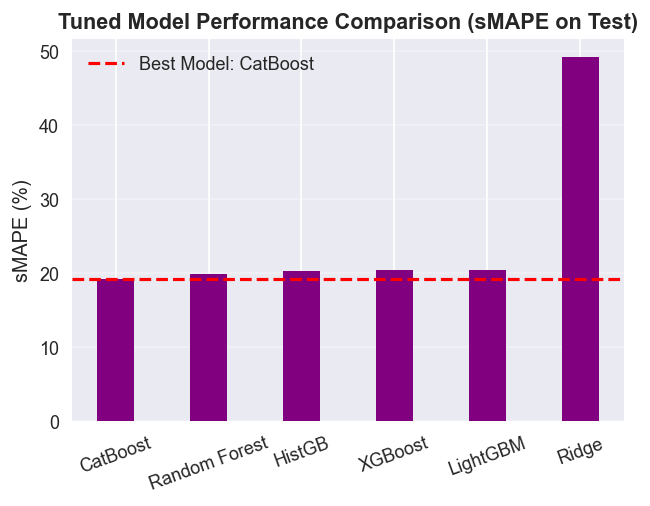

In [62]:
plt.figure(figsize=(5, 4))
plt.bar(final_df["Model"], final_df["sMAPE (%)"], color="purple", width=0.4)
plt.axhline(best_model_smape, color="red", linestyle="--", label=f"Best Model: {best_model_name}")
plt.title("Tuned Model Performance Comparison (sMAPE on Test)", fontweight="bold")
plt.ylabel("sMAPE (%)")
plt.xticks(rotation=20)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Actual v/s Predicted

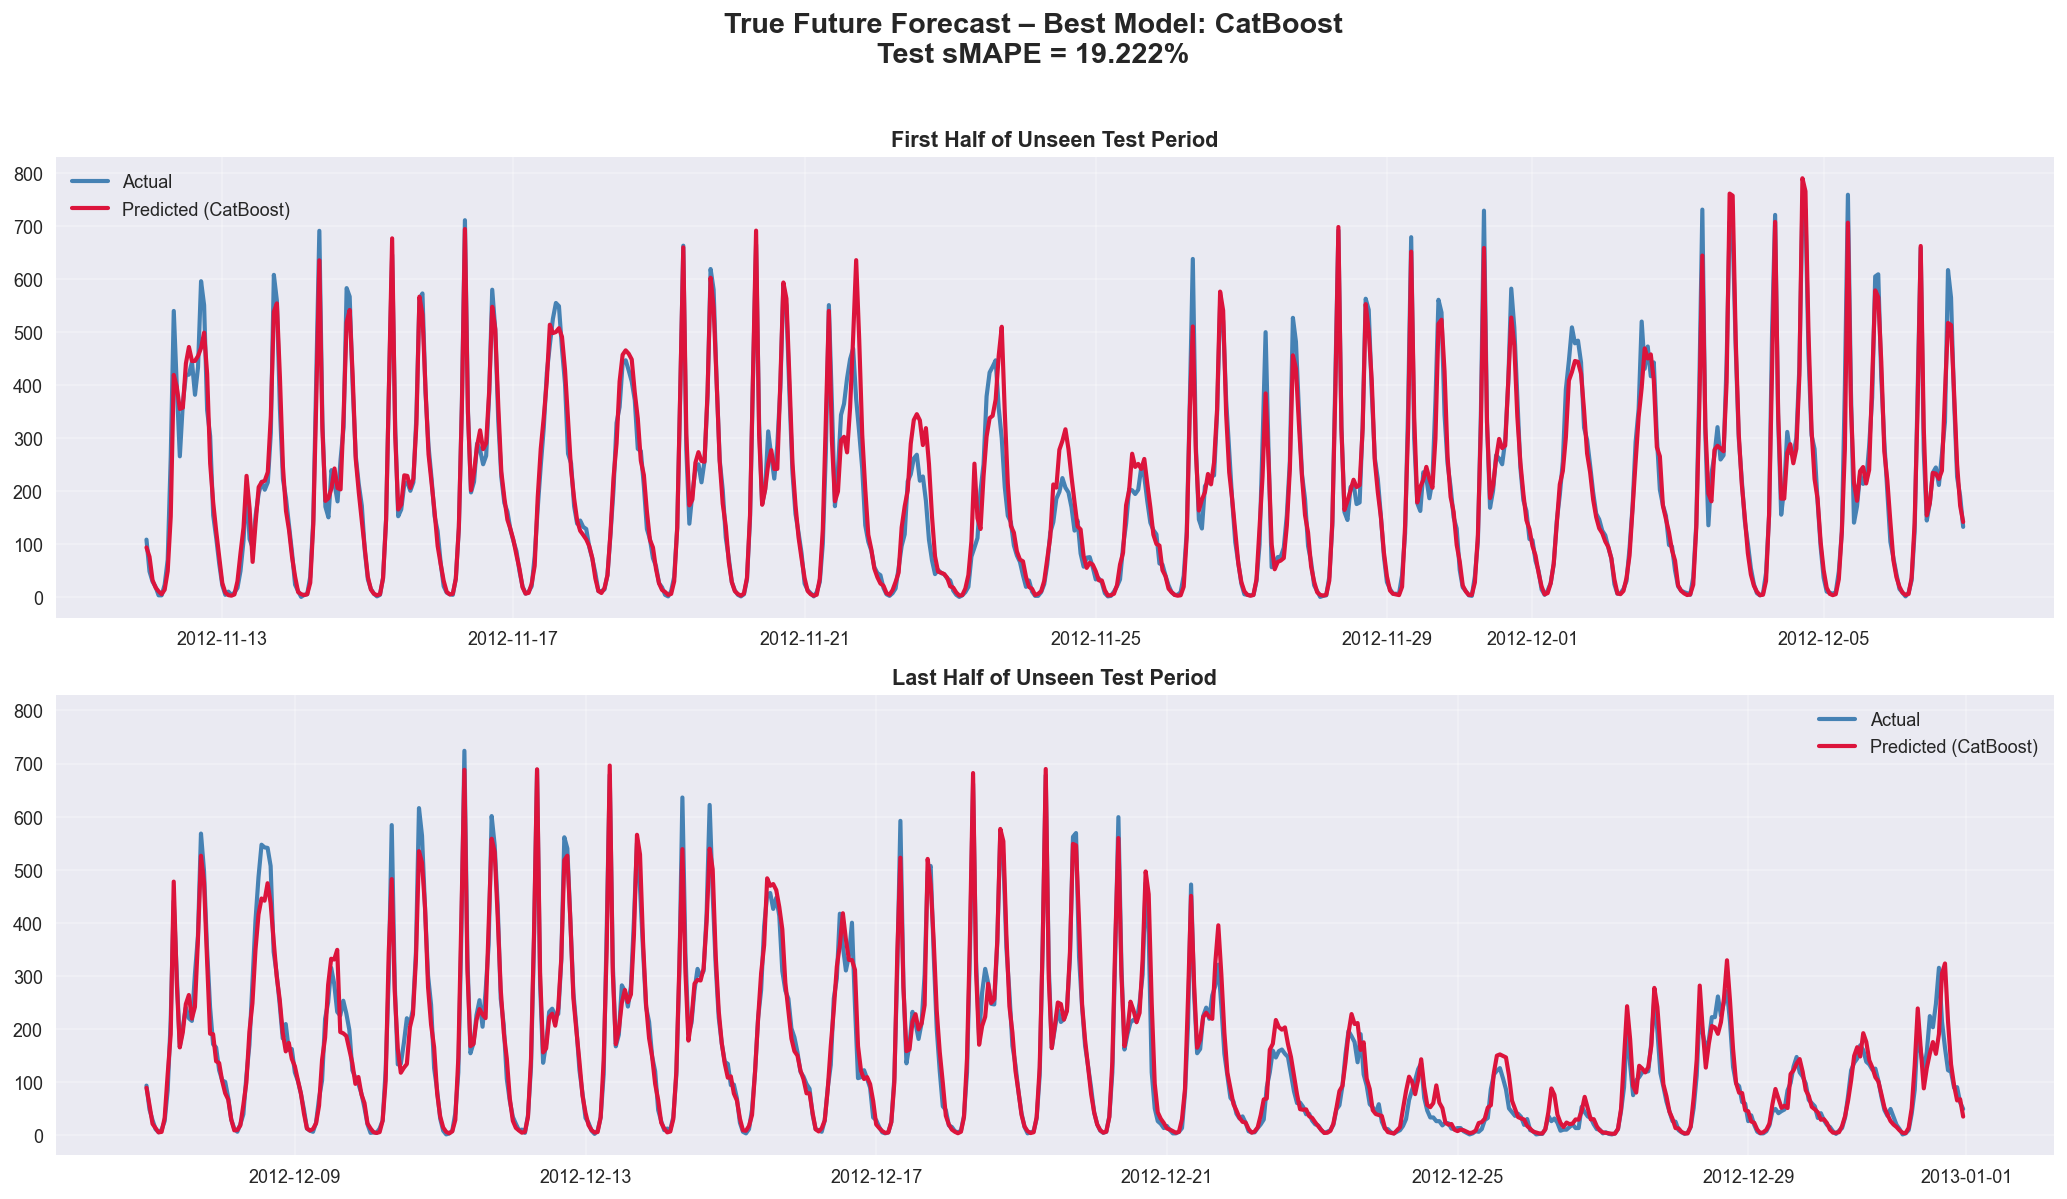

In [65]:
best_model_pred = np.expm1(best_model.predict(X_test))
mid = len(test_clean) // 2
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharey=True)

for i, ax in enumerate(axes):
    s, e = (0, mid) if i == 0 else (mid, None)
    ax.plot(
        test_clean["datetime"].iloc[s:e],
        y_test.iloc[s:e],
        label="Actual",
        linewidth=2.3,
        color="steelblue",
    )
    ax.plot(
        test_clean["datetime"].iloc[s:e],
        best_model_pred[s:e],
        label=f"Predicted ({best_model_name})",
        linewidth=2.3,
        color="crimson",
    )
    ax.set_title(
        f"{'First' if i == 0 else 'Last'} Half of Unseen Test Period",
        fontweight="bold",
    )
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(
    f"True Future Forecast – Best Model: {best_model_name}\n"
    f"Test sMAPE = {best_model_smape:.3f}%",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

### High/Low demand classification


High/Normal/Low Demand Classification Accuracy (Test): 91.7%


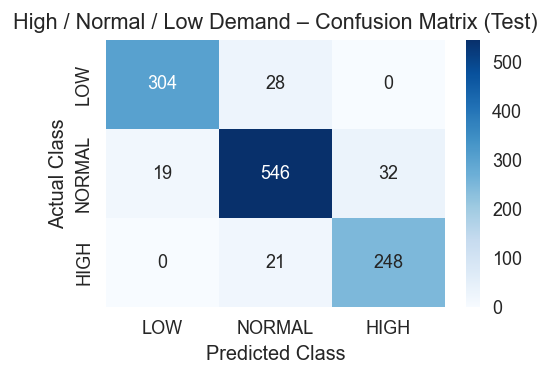

In [75]:
q75, q25 = train_clean["cnt"].quantile(0.75), train_clean["cnt"].quantile(0.25)
class_df = pd.DataFrame({"actual": y_test.values, "predicted": best_model_pred})

actual_class = np.where(
    class_df["actual"] > q75,
    "HIGH",
    np.where(class_df["actual"] < q25, "LOW", "NORMAL"),
)
pred_class = np.where(
    class_df["predicted"] > q75,
    "HIGH",
    np.where(class_df["predicted"] < q25, "LOW", "NORMAL"),
)

class_df["actual_class"] = actual_class
class_df["pred_class"] = pred_class

acc = (class_df["actual_class"] == class_df["pred_class"]).mean()
print(f"\nHigh/Normal/Low Demand Classification Accuracy (Test): {acc:.1%}")

labels = ["LOW", "NORMAL", "HIGH"]
cm = confusion_matrix(actual_class, pred_class, labels=labels)

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("High / Normal / Low Demand – Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

### Weather Sensitive Analysis

In [71]:
test_with_hr = test_clean.copy()
test_with_hr['hr'] = test_clean['datetime'].dt.hour
morning_8am = test_with_hr[test_with_hr['hr'] == 8]
base_features = morning_8am[feature_cols].median()

results = []
baseline_pred = None

for temp_c in range(0, 36, 5):
    temp_f = int(temp_c * 9/5 + 32)
    
    row = base_features.copy()
    row['temp'] = temp_c / 41.0
    row['atemp'] = (temp_c + 3) / 50.0
    row['temp_sq'] = row['temp'] ** 2
    row['temp_cubed'] = row['temp'] ** 3
    row['feels_like'] = row['temp'] * (1 - row['hum'])
    
    X_in = pd.DataFrame([row], columns=feature_cols)
    pred = int(round(np.expm1(best_model.predict(X_in))[0]))
    
    if temp_c == 15:
        baseline_pred = pred
        change = "Baseline"
    else:
        # Only calculate change AFTER baseline is set
        change = f"{pred - baseline_pred:+4d} bikes" if baseline_pred is not None else "—"
    
    results.append({
        "Temperature (°F)": f"{temp_f}°F",
        "Temperature (°C)": f"{temp_c}°C",
        "Predicted 8 AM Demand": pred,
        "Change vs 59°F": change
    })

results_df = pd.DataFrame(results)

styled_table = (results_df.style
    .set_caption("WEATHER SENSITIVITY ANALYSIS – 8 AM RUSH HOUR")
    .set_table_styles([
        {'selector': 'caption', 'props': 'font-size: 18px; font-weight: bold; color: #8E24AA; text-align: center; margin-bottom: 10px;'},
        {'selector': 'th', 'props': 'background-color: #1976D2; color: white; font-weight: bold; text-align: center;'},
        {'selector': 'td', 'props': 'text-align: center; font-size: 14px;'}
    ])
    .background_gradient(cmap="Blues", subset=["Predicted 8 AM Demand"])
    .format({
        "Predicted 8 AM Demand": "{:,} bikes",
        "Change vs 59°F": "{}"
    })
)

display(styled_table)

,Temperature (°F),Temperature (°C),Predicted 8 AM Demand,Change vs 59°F
0,32°F,0°C,493 bikes,—
1,41°F,5°C,492 bikes,—
2,50°F,10°C,498 bikes,—
3,59°F,15°C,517 bikes,Baseline
4,68°F,20°C,524 bikes,+7 bikes
5,77°F,25°C,514 bikes,-3 bikes
6,86°F,30°C,508 bikes,-9 bikes
7,95°F,35°C,494 bikes,-23 bikes


### Live forecast function

In [72]:
def get_weather():
    url = (
        "https://api.open-meteo.com/v1/forecast"
        "?latitude=38.9072&longitude=-77.0369"
        "&hourly=temperature_2m,relative_humidity_2m,wind_speed_10m"
        "&forecast_days=2&timezone=America%2FNew_York"
    )
    data = requests.get(url, timeout=15).json()
    dfw = pd.DataFrame(
        {
            "datetime": pd.to_datetime(data["hourly"]["time"]).tz_localize(None),
            "temp": data["hourly"]["temperature_2m"],
            "hum": np.array(data["hourly"]["relative_humidity_2m"]) / 100.0,
            "windspeed": data["hourly"]["wind_speed_10m"],
        }
    )
    now = pd.Timestamp.now(LOCAL_TZ).floor("h").tz_localize(None)
    return dfw[dfw["datetime"] >= now].head(48).reset_index(drop=True)

def live_forecast_24h(model, last_row_dict, weather_df, feature_cols, cnt_hist):

    preds = []
    times = []

    # Start from last known feature row
    state = last_row_dict.copy()

    # Initialize lag values from history
    series = np.asarray(cnt_hist, dtype=float)
    lag1 = float(series[-1])
    lag2 = float(series[-2]) if len(series) >= 2 else lag1

    last_24 = deque(series[-24:].tolist() if len(series) >= 24 else [lag1] * 24, maxlen=24)
    last_48 = deque(series[-48:].tolist() if len(series) >= 48 else [lag1] * 48, maxlen=48)
    last_168 = deque(series[-168:].tolist() if len(series) >= 168 else [lag1] * 168, maxlen=168)

    roll3 = deque(series[-3:].tolist() if len(series) >= 3 else [lag1] * 3, maxlen=3)
    roll12 = deque(series[-12:].tolist() if len(series) >= 12 else [lag1] * 12, maxlen=12)
    roll24 = deque(series[-24:].tolist() if len(series) >= 24 else [lag1] * 24, maxlen=24)

    # One-hot groups
    season_cols = [c for c in feature_cols if c.startswith("season_")]
    weath_cols  = [c for c in feature_cols if c.startswith("weathersit_")]
    mnth_cols   = [c for c in feature_cols if c.startswith("mnth_")]
    wday_cols   = [c for c in feature_cols if c.startswith("weekday_")]

    for i in range(min(24, len(weather_df))):
        t = weather_df.loc[i, "datetime"]
        times.append(t)

        # TIME FEATURES
        hr = t.hour
        #Dataset weekday: Sunday=0,...,Saturday=6
        wd = (t.weekday() + 1) % 7
        mn = t.month

        state["hr"] = hr
        state["weekday"] = wd
        state["mnth"] = mn

        state["hour_sin"] = np.sin(2 * np.pi * hr / 24)
        state["hour_cos"] = np.cos(2 * np.pi * hr / 24)
        state["day_sin"]  = np.sin(2 * np.pi * wd / 7)
        state["month_sin"] = np.sin(2 * np.pi * mn / 12)
        state["month_cos"] = np.cos(2 * np.pi * mn / 12)

        # WEATHER FEATURES
        state["temp"] = weather_df.loc[i, "temp"]
        state["hum"] = weather_df.loc[i, "hum"]
        state["windspeed"] = weather_df.loc[i, "windspeed"]
        state["temp_sq"] = state["temp"] ** 2
        state["temp_cubed"] = state["temp"] ** 3
        state["feels_like"] = state["temp"] * (1 - state["hum"])

        # CALENDAR-STYLE FIELDS
        state["days_since_start"] = (t - df["datetime"].min()).days
        state["is_holiday"] = 0  # could refine with a live holiday calendar
        state["is_weekend"] = int(wd in [0, 6])  # dataset convention (0=Sun,6=Sat)

        # Rush hour (same as training)
        state["is_rush_hour"] = int(hr in [7, 8, 9, 17, 18, 19])
        state["rush_work"] = state["is_rush_hour"] * state.get("workingday", 1)

        # LAGS & ROLLING STATS
        state["lag_1h"] = lag1
        state["lag_2h"] = lag2
        state["lag_24h"] = last_24[0]
        state["lag_48h"] = last_48[0]
        state["lag_168h"] = last_168[0]

        state["roll_mean_3h"]  = float(np.mean(roll3))
        state["roll_mean_12h"] = float(np.mean(roll12))
        state["roll_mean_24h"] = float(np.mean(roll24))
        state["roll_std_24h"]  = float(np.std(roll24)) if len(roll24) > 1 else 0.0
        state["roll_max_24h"]  = float(np.max(roll24))

        # RESET ONE-HOTS
        for col in season_cols + weath_cols + mnth_cols + wday_cols:
            state[col] = 0

        # month one-hot
        mn_col = f"mnth_{mn}"
        if mn_col in mnth_cols:
            state[mn_col] = 1

        # weekday one-hot
        wd_col = f"weekday_{wd}"
        if wd_col in wday_cols:
            state[wd_col] = 1

        # season approximate: 1=winter,2=spring,3=summer,4=fall
        if 3 <= mn <= 5:
            season_idx = 2
        elif 6 <= mn <= 8:
            season_idx = 3
        elif 9 <= mn <= 11:
            season_idx = 4
        else:
            season_idx = 1
        season_col = f"season_{season_idx}"
        if season_col in season_cols:
            state[season_col] = 1

        # conservative moderate weather
        if "weathersit_2" in weath_cols:
            state["weathersit_2"] = 1

        # building input in exact training order
        x_input = pd.DataFrame([state]).reindex(columns=feature_cols, fill_value=0)

        # Predict
        yhat_log = model.predict(x_input)[0]
        yhat = float(np.expm1(yhat_log))
        yhat = max(0.0, yhat)
        preds.append(yhat)

        # Updating lags/rolling
        lag2 = lag1
        lag1 = yhat
        last_24.append(yhat)
        last_48.append(yhat)
        last_168.append(yhat)
        roll3.append(yhat)
        roll12.append(yhat)
        roll24.append(yhat)

    return pd.DataFrame({"Time": times, "Predicted Demand": preds})

### Plotting Live Forecast

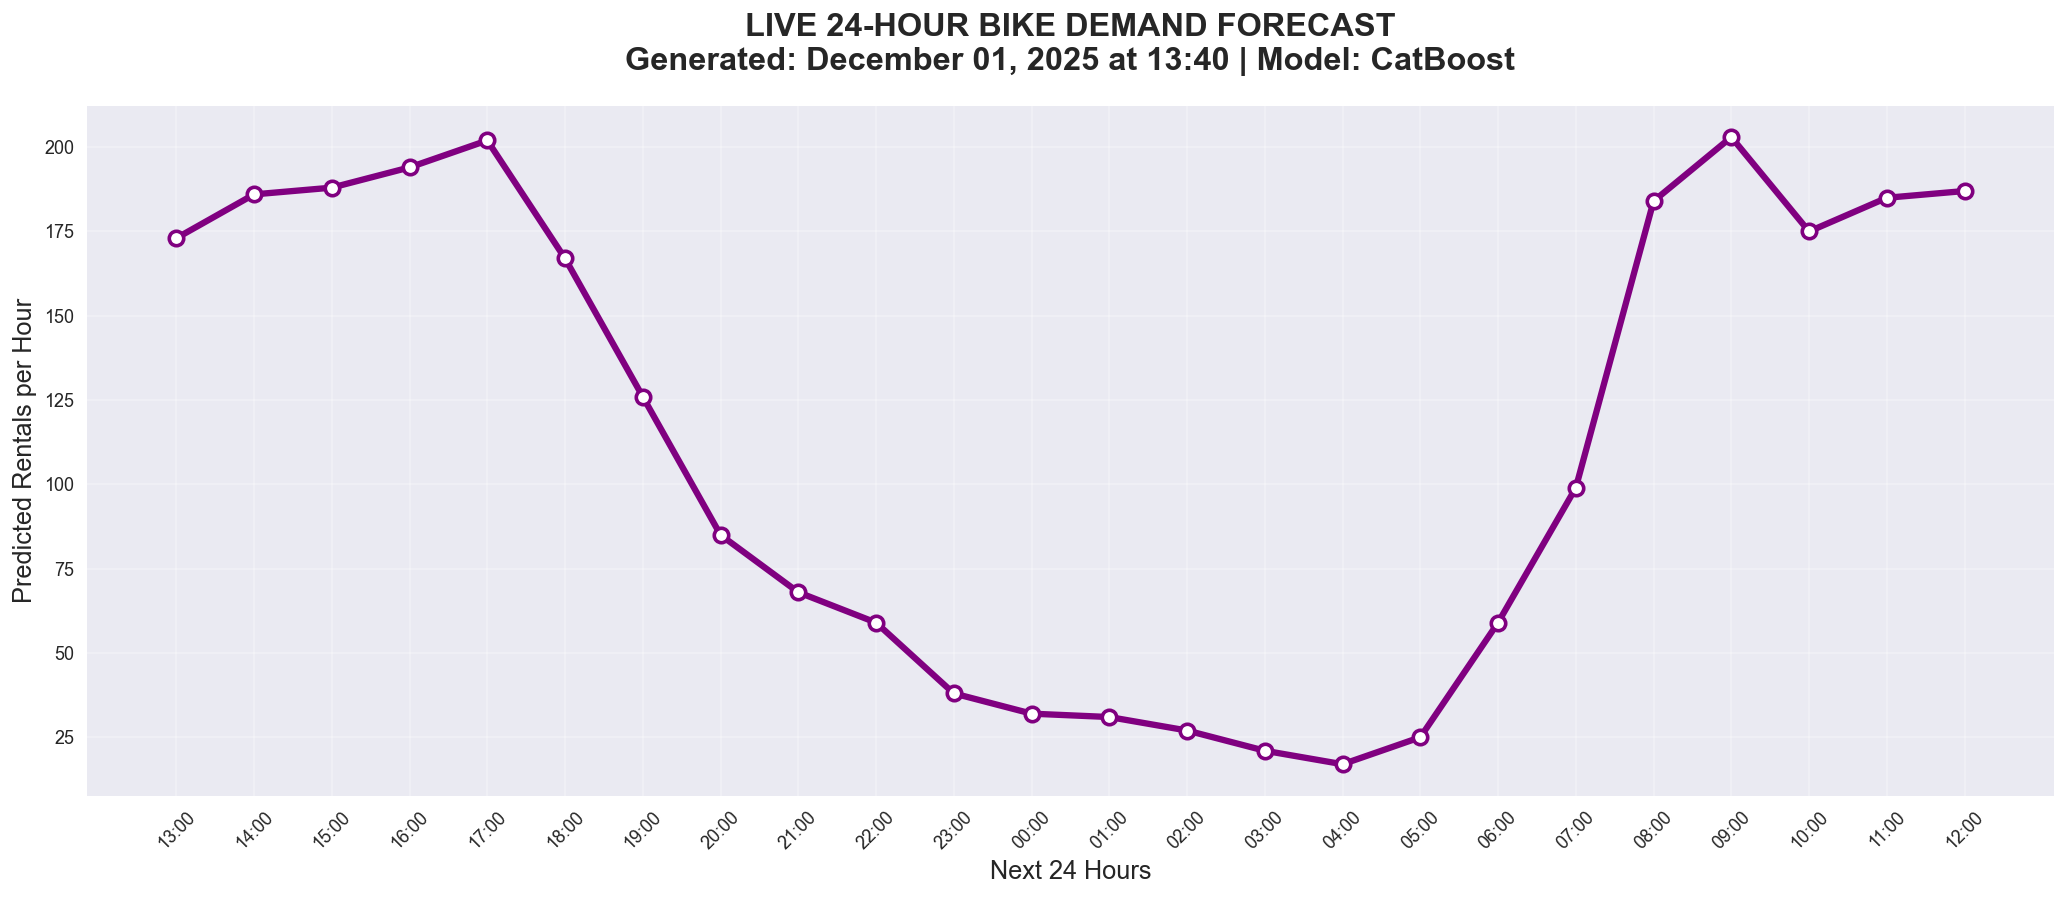


NEXT 24 HOURS — HOURLY PREDICTION


,Time,Predicted Demand,Temperature (°F),Weather
0,"Dec 01, 13:00",173,44.8°F,Unknown
1,"Dec 01, 14:00",186,45.3°F,Unknown
2,"Dec 01, 15:00",188,45.3°F,Unknown
3,"Dec 01, 16:00",194,44.4°F,Unknown
4,"Dec 01, 17:00",202,40.8°F,Unknown
5,"Dec 01, 18:00",167,38.7°F,Unknown
6,"Dec 01, 19:00",126,36.3°F,Unknown
7,"Dec 01, 20:00",85,34.9°F,Unknown
8,"Dec 01, 21:00",68,33.8°F,Unknown
9,"Dec 01, 22:00",59,33.1°F,Unknown


In [79]:
weather = get_weather()
last_row = X_train.iloc[-1].to_dict()
live = live_forecast_24h(best_model, last_row, weather, feature_cols, cnt_history)

# Round predictions
live["Predicted Demand"] = live["Predicted Demand"].round().astype(int)

plt.figure(figsize=(16, 7))
plt.plot(
    live["Time"].dt.strftime("%H:%M"),
    live["Predicted Demand"],
    "o-", color="purple", linewidth=3.5, markersize=8,
    markerfacecolor="white", markeredgewidth=2
)
plt.title(f"LIVE 24-HOUR BIKE DEMAND FORECAST\n"
          f"Generated: {datetime.now(LOCAL_TZ).strftime('%B %d, %Y at %H:%M')} | Model: {best_model_name}",
          fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Next 24 Hours", fontsize=14)
plt.ylabel("Predicted Rentals per Hour", fontsize=14)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Clean & Safe table display
live_table = live.copy()

# Format time
live_table["Time"] = live_table["Time"].dt.strftime("%b %d, %H:%M")

# Use the actual temperature from weather forecast
if "temp" in weather.columns:
    temp_c = weather["temp"].values[:24]  # Next 24 hours
    temp_f = (temp_c * 9/5) + 32
    live_table["Temperature (°F)"] = [f"{t:.1f}°F" for t in temp_f]
else:
    live_table["Temperature (°F)"] = "N/A"

# Weather description from weathersit.
if "weathersit" in live_table.columns:
    weather_map = {1: "Clear/Sunny", 2: "Cloudy/Mist", 3: "Light Rain/Snow", 4: "Heavy Rain/Storm"}
    live_table["Weather"] = live_table["weathersit"].map(weather_map)
else:
    live_table["Weather"] = "Unknown"

final_display = live_table[["Time", "Predicted Demand", "Temperature (°F)", "Weather"]].copy()

print("\nNEXT 24 HOURS — HOURLY PREDICTION")
display(final_display.head(24).style
    .background_gradient(cmap="Purples", subset=["Predicted Demand"])
    .set_properties(**{'text-align': 'center'})
    .set_caption("LIVE 24-HOUR DEMAND FORECAST")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('color', 'rebeccapurple')]}
    ])
)